# OPTICS free implementation 

Heavily inspired from https://github.com/scikit-learn/scikit-learn/blob/fe2edb3cdbd75ae4e662fda67dcb19277258792b/sklearn/cluster/_optics.py

In [1]:
#Imports 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# Imports 
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from matplotlib.colors import hsv_to_rgb
import tifffile as tiff
import math
from sklearn.cluster import OPTICS
import matplotlib.gridspec as gridspec
from tqdm import tqdm

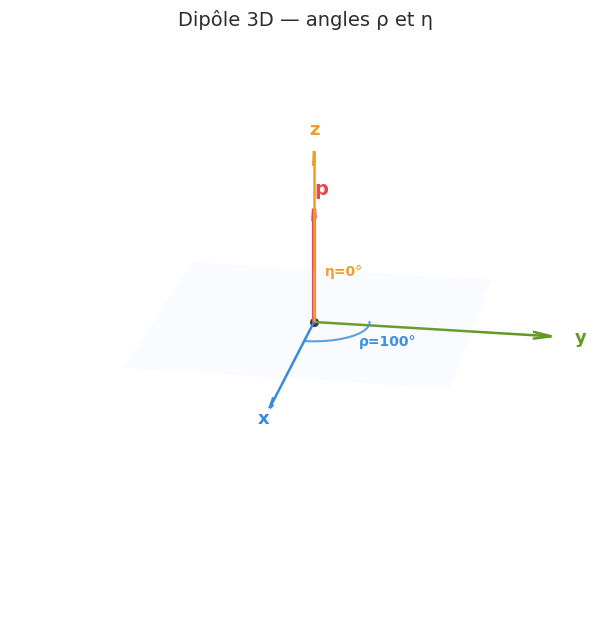

In [6]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.widgets import Slider
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ── couleurs ──────────────────────────────────────────────────────────────────
C_DIPOLE  = "#E24B4A"
C_X       = "#378ADD"
C_Y       = "#639922"
C_Z       = "#EF9F27"
C_PROJ    = "#888780"
C_ARC_RHO = "#378ADD"
C_ARC_ETA = "#EF9F27"
C_PLAN    = "#B5D4F4"

# ── paramètres initiaux ───────────────────────────────────────────────────────
RHO0, ETA0 = 30.0, 30.0
AXIS_LEN   = 1.5   # longueur des axes
DIPOLE_LEN = 1.0    # longueur du vecteur dipôle
ARC_R      = 0.35   # rayon des arcs d'angle


def dipole_vector(rho_deg, eta_deg):
    r, e = np.radians(rho_deg), np.radians(eta_deg)
    return np.array([np.sin(e)*np.cos(r),
                     np.sin(e)*np.sin(r),
                     np.cos(e)]) * DIPOLE_LEN


def draw_arc(ax, start_vec, end_vec, radius, color, n=60, lw=1.4):
    """Arc sphérique de start_vec à end_vec de rayon radius."""
    s = start_vec / np.linalg.norm(start_vec)
    e = end_vec   / np.linalg.norm(end_vec)
    t = np.linspace(0, 1, n)
    pts = np.outer(np.sin((1-t)*np.pi/2), s*0) # init
    pts = np.array([(1-ti)*s + ti*e for ti in t])
    norms = np.linalg.norm(pts, axis=1, keepdims=True)
    pts = pts / norms * radius
    ax.plot(pts[:,0], pts[:,1], pts[:,2],
            color=color, lw=lw, alpha=0.85, zorder=5)


def arrow3d(ax, vec, color, lw=2.5, head=0.06, label=None):
    ax.quiver(0, 0, 0, vec[0], vec[1], vec[2],
              color=color, linewidth=lw,
              arrow_length_ratio=head/np.linalg.norm(vec),
              zorder=10, label=label)


def plot_plane_xy(ax, r=1.0, alpha=0.08):
    xx = np.array([[-r, r, r, -r]])
    yy = np.array([[-r, -r, r,  r]])
    zz = np.zeros_like(xx)
    poly = Poly3DCollection([list(zip(xx[0], yy[0], zz[0]))],
                             alpha=alpha, facecolor=C_PLAN, edgecolor='none')
    ax.add_collection3d(poly)
    # cercle unité dans le plan xy
    #theta = np.linspace(0, 2*np.pi, 120)
    #ax.plot(np.cos(theta)*r*0.9, np.sin(theta)*r*0.9, np.zeros(120),
    #        color=C_PROJ, lw=0.6, ls='--', alpha=0.4)


def update(rho,eta):
    rho = s_rho
    eta = s_eta 
    r, e = np.radians(rho), np.radians(eta)

    p = dipole_vector(rho, eta)

    ax.cla()

    # ── plan xy ──────────────────────────────────────────────────────────────
    plot_plane_xy(ax)

    # ── axes ─────────────────────────────────────────────────────────────────
    for vec, col, lbl in [
        ([AXIS_LEN,0,0], C_X, 'x'),
        ([0,AXIS_LEN,0], C_Y, 'y'),
        ([0,0,AXIS_LEN], C_Z, 'z'),
    ]:
        ax.quiver(0, 0, 0, vec[0], vec[1], vec[2],
                  color=col, linewidth=1.8,
                  arrow_length_ratio=0.08,
                  zorder=6)
        offset = np.array(vec) * 1.12
        ax.text(*offset, lbl, color=col, fontsize=13, fontweight='bold',
                ha='center', va='center')

    # ── projections pointillées ───────────────────────────────────────────────
    px, py, pz = p
    # projection sur le plan xy
    ax.plot([0, px], [0, py], [0, 0],
            color=C_PROJ, lw=1, ls='--', alpha=0.7, zorder=3)
    # ligne verticale de la projection au dipôle
    ax.plot([px, px], [py, py], [0, pz],
            color=C_PROJ, lw=1, ls='--', alpha=0.7, zorder=3)
    # projection sur x
    ax.plot([0, px], [0, 0], [0, 0],
            color=C_X, lw=0.9, ls='--', alpha=0.5, zorder=3)
    # projection sur y
    ax.plot([0, 0], [0, py], [0, 0],
            color=C_Y, lw=0.9, ls='--', alpha=0.5, zorder=3)
    # point projection plan xy
    ax.scatter([px], [py], [0], color=C_PROJ, s=20, zorder=7, alpha=0.8)

    # ── arc ρ (dans le plan xy de l'axe x à la projection) ────────────────────
    n_arc = max(2, int(abs(rho)))
    t_rho = np.linspace(0, r, n_arc+1)
    ax.plot(np.cos(t_rho)*ARC_R, np.sin(t_rho)*ARC_R, np.zeros(n_arc+1),
            color=C_ARC_RHO, lw=1.5, alpha=0.85, zorder=5)
    # label ρ
    mid_r = r / 2
    ax.text(np.cos(mid_r)*(ARC_R+0.08),
            np.sin(mid_r)*(ARC_R+0.08),
            -0.05,
            f'ρ={rho:.0f}°', color=C_ARC_RHO, fontsize=10, fontweight='bold')

    # ── arc η (dans le plan azimutal, de la projection au dipôle) ─────────────
    n_arc2 = max(2, int(abs(eta)))
    t_eta = np.linspace(0, e, n_arc2+1)
    ax.plot(np.cos(t_eta)*np.cos(r)*ARC_R,
            np.cos(t_eta)*np.sin(r)*ARC_R,
            np.sin(t_eta)*ARC_R,
            color=C_ARC_ETA, lw=1.5, alpha=0.85, zorder=5)
    # label η
    mid_e = e / 2 if e != 0 else 0.15
    ax.text(np.sin(mid_e)*np.cos(r)*(ARC_R+0.10),
            np.sin(mid_e)*np.sin(r)*(ARC_R+0.10),
            np.cos(mid_e)*(ARC_R+0.06),
            f'η={eta:.0f}°', color=C_ARC_ETA, fontsize=10, fontweight='bold')

    # ── vecteur dipôle ────────────────────────────────────────────────────────
    ax.quiver(0, 0, 0, px, py, pz,
              color=C_DIPOLE, linewidth=3,
              arrow_length_ratio=0.10,
              zorder=10)
    ax.text(px*1.12, py*1.12, pz*1.12, 'p',
            color=C_DIPOLE, fontsize=14, fontweight='bold')

    # ── origine ───────────────────────────────────────────────────────────────
    ax.scatter([0], [0], [0], color='#2C2C2A', s=30, zorder=12)

    # ── composantes numériques ────────────────────────────────────────────────
    '''ax.set_title(
        f'px = {px:.3f}    py = {py:.3f}    pz = {pz:.3f}',
        fontsize=11, color='#444441', pad=8
    )'''

    # ── mise en forme ─────────────────────────────────────────────────────────
    lim = 1.2
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel('x', labelpad=4, color=C_X, fontweight='bold')
    ax.set_ylabel('y', labelpad=4, color=C_Y, fontweight='bold')
    ax.set_zlabel('z', labelpad=4, color=C_Z, fontweight='bold')
    ax.tick_params(labelsize=8, colors='#888780')
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#D3D1C7')
    ax.yaxis.pane.set_edgecolor('#D3D1C7')
    ax.zaxis.pane.set_edgecolor('#D3D1C7')
    ax.grid(False)
    ax.set_axis_off()
    ax.view_init(elev=20, azim=10)
    #ax.grid(True, lw=0.4, alpha=0.4)

    # ── légende ───────────────────────────────────────────────────────────────
    '''legend_elements = [
        mpatches.Patch(color=C_DIPOLE, label='dipôle p'),
        mpatches.Patch(color=C_X,      label='axe x'),
        mpatches.Patch(color=C_Y,      label='axe y'),
        mpatches.Patch(color=C_Z,      label='axe z'),
        mpatches.Patch(color=C_PROJ,   label='projections'),
    ]
    ax.legend(handles=legend_elements, loc='upper left',
              fontsize=8, framealpha=0.6,
              bbox_to_anchor=(-0.12, 1.0))'''

    fig.canvas.draw_idle()


# ── figure & axes ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 8), facecolor='white')
fig.suptitle('Dipôle 3D — angles ρ et η', fontsize=14,
             fontweight='500', color='#2C2C2A', y=0.97)

ax = fig.add_axes([0.05, 0.20, 0.90, 0.74], projection='3d')
ax.set_facecolor('white')

# ── sliders ───────────────────────────────────────────────────────────────────
#ax_rho = fig.add_axes([0.15, 0.10, 0.70, 0.025], facecolor='#F1EFE8')
#ax_eta = fig.add_axes([0.15, 0.05, 0.70, 0.025], facecolor='#F1EFE8')

s_rho = 100.0
s_eta = 0.0

update(s_rho, s_eta)



plt.show()

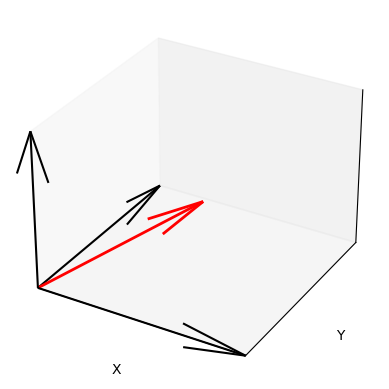

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Parameters ----
rho = np.pi / 4      # angle in xy-plane (azimuth)
eta = np.pi / 6      # elevation angle
r = 1.0              # length of the vector

# ---- Convert to Cartesian ----
x = r * np.cos(eta) * np.cos(rho)
y = r * np.cos(eta) * np.sin(rho)
z = r * np.sin(eta)

# ---- Plot ----
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Draw vector
ax.quiver(0, 0, 0, x, y, z, color='r', linewidth=2)

# Draw axes manually
axis_length = 1.2
ax.quiver(0, 0, 0, axis_length, 0, 0, color='k')  # x-axis
ax.quiver(0, 0, 0, 0, axis_length, 0, color='k')  # y-axis
ax.quiver(0, 0, 0, 0, 0, axis_length, color='k')  # z-axis

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Limits
ax.set_xlim([0, axis_length])
ax.set_ylim([0, axis_length])
ax.set_zlim([0, axis_length])

# Remove grid
ax.grid(False)

# Optional: cleaner look
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.show()

In [57]:
"""
Génération des frames pour le GIF du dipôle 3D
================================================
Trajectoire (bouclée) :
  rho45 eta0  →  rho45  eta45  →  rho135 eta45  →  rho135 eta90  →  (retour)

15 secondes à 25 fps = 375 frames au total, réparties en 4 segments égaux.
Les frames sont sauvegardées dans OUT_DIR sous le nom frame_0000.png … frame_0374.png
"""

import os
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ── dossier de sortie ─────────────────────────────────────────────────────────
OUT_DIR =r"C:\Users\LOCCO\Project_Curie\frames_dipole"
os.makedirs(OUT_DIR, exist_ok=True)

# ── paramètres GIF ────────────────────────────────────────────────────────────
FPS        = 15
DURATION_S = 8
N_FRAMES   = FPS * DURATION_S          # 375

# ── keyframes (rho, eta) ──────────────────────────────────────────────────────
KEYFRAMES = [
    ( 45,  0),
    ( 45, 45),
    (135, 45),
    (135, 90),
    (45,0)
]
N_SEG   = len(KEYFRAMES)               # 4 segments, boucle sur le 1er
N_PER_SEG = N_FRAMES // N_SEG         # ~93 frames par segment

rhos, etas = [], []
frame_idx = 0
for seg in range(N_SEG):
    rho0, eta0 = KEYFRAMES[seg]
    rho1, eta1 = KEYFRAMES[(seg + 1) % N_SEG]
    n = N_PER_SEG if seg < N_SEG - 1 else N_FRAMES - frame_idx
    for i in range(n):
        t = i / n
        rhos.append(slerp_angle(rho0, rho1, t))
        etas.append(slerp_angle(eta0, eta1, t))
        frame_idx += 1

rhos = np.array(rhos)   
etas = np.array(etas)  
# ── couleurs ──────────────────────────────────────────────────────────────────
C_DIPOLE  = "#990000"
C_X       = "#000000"
C_Y       = "#000000"
C_Z       = "#000000"
C_PROJ    = "#E49A9A"
C_ARC_RHO = "#838383"
C_ARC_ETA = "#838383"
C_PLAN    = "#F3F3F3"

AXIS_LEN   = 1.15
DIPOLE_LEN = 1.0
ARC_R      = 0.35


# ── fonctions ─────────────────────────────────────────────────────────────────
def dipole_vector(rho_deg, eta_deg):
    r, e = np.radians(rho_deg), np.radians(eta_deg)
    return np.array([np.sin(e)*np.cos(r),
                     np.sin(e)*np.sin(r),
                     np.cos(e)]) * DIPOLE_LEN


def plot_plane_xy(ax, r=1.0, alpha=0.08):
    xx = np.array([[-r, r, r, -r]])
    yy = np.array([[-r, -r, r, r]])
    zz = np.zeros_like(xx)
    poly = Poly3DCollection([list(zip(xx[0], yy[0], zz[0]))],
                            alpha=alpha, facecolor=C_PLAN, edgecolor='none')
    ax.add_collection3d(poly)
    theta = np.linspace(0, 2*np.pi, 120)
    ax.plot(np.cos(theta)*r*0.9, np.sin(theta)*r*0.9, np.zeros(120),
            color=C_PROJ, lw=0.6, ls='--', alpha=0.4)


def draw_frame(ax, fig, rho, eta):
    r, e = np.radians(rho), np.radians(eta)
    p = dipole_vector(rho, eta)
    ax.cla()

    plot_plane_xy(ax)

    for vec, col, lbl in [
        ([AXIS_LEN, 0, 0], C_X, 'x'),
        ([0, AXIS_LEN, 0], C_Y, 'y'),
        ([0, 0, AXIS_LEN], C_Z, 'z'),
    ]:
        ax.quiver(0, 0, 0, vec[0], vec[1], vec[2],
                  color=col, linewidth=1.8, arrow_length_ratio=0.08, zorder=6)
        offset = np.array(vec) * 1.12
        ax.text(*offset, lbl, color=col, fontsize=13, fontweight='bold',
                ha='center', va='center')

    px, py, pz = p
    ax.plot([0, px], [0, py], [0, 0],   color=C_PROJ, lw=1, ls='--', alpha=0.7, zorder=3)
    ax.plot([px, px], [py, py], [0, pz], color=C_PROJ, lw=1, ls='--', alpha=0.7, zorder=3)
    ax.plot([0, px], [0, 0],   [0, 0],  color=C_X,    lw=0.9, ls='--', alpha=0.5, zorder=3)
    ax.plot([0, 0],  [0, py],  [0, 0],  color=C_Y,    lw=0.9, ls='--', alpha=0.5, zorder=3)
    ax.scatter([px], [py], [0], color=C_PROJ, s=20, zorder=7, alpha=0.8)

    # arc ρ
    n_arc = max(2, int(abs(rho)))
    t_rho = np.linspace(0, r, n_arc + 1)
    ax.plot(np.cos(t_rho)*ARC_R, np.sin(t_rho)*ARC_R, np.zeros(n_arc + 1),
            color=C_ARC_RHO, lw=1.5, alpha=0.85, zorder=5)
    mid_r = r / 2
    ax.text(np.cos(mid_r)*(ARC_R+0.08), np.sin(mid_r)*(ARC_R+0.08), -0.05,
            f'ρ={rho:.0f}°', color=C_ARC_RHO, fontsize=10, fontweight='bold')

    # arc η
    n_arc2 = max(2, int(abs(eta)))
    t_eta = np.linspace(0, e, n_arc2 + 1)
    ax.plot(np.sin(t_eta)*np.cos(r)*ARC_R,
            np.sin(t_eta)*np.sin(r)*ARC_R,
            np.cos(t_eta)*ARC_R,
            color=C_ARC_ETA, lw=1.5, alpha=0.85, zorder=5)
    mid_e = e / 2 if abs(e) > 0.05 else 0.12
    ax.text(np.sin(mid_e)*np.cos(r)*(ARC_R+0.12),
            np.sin(mid_e)*np.sin(r)*(ARC_R+0.12),
            np.cos(mid_e)*(ARC_R+0.08),
            f'η={eta:.0f}°', color=C_ARC_ETA, fontsize=10, fontweight='bold')

    # dipôle
    ax.quiver(0, 0, 0, px, py, pz,
              color=C_DIPOLE, linewidth=3, arrow_length_ratio=0.10, zorder=10)
    ax.text(px*1.12, py*1.12, pz*1.12, 'p', color=C_DIPOLE, fontsize=14, fontweight='bold')
    ax.scatter([0], [0], [0], color='#2C2C2A', s=30, zorder=12)

    #ax.set_title(f'ρ = {rho:.1f}°    η = {eta:.1f}°',fontsize=11, color='#444441', pad=8)

    lim = 1.2

    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_axis_off()                          # pas de boîte, pas de grille, pas de ticks
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    ax.view_init(elev=20, azim=10)
    ax.view_init(elev=20, azim=10)


def slerp_angle(a0, a1, t):
    """Interpolation linéaire (sur les angles) avec easing cosinus."""
    t_ease = 0.5 - 0.5 * np.cos(np.pi * t)
    return a0 + (a1 - a0) * t_ease


# ── génération ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(6, 6), facecolor='white')
ax  = fig.add_axes([0.05, 0.05, 0.90, 0.90], projection='3d')
ax.set_facecolor('white')

frame_idx = 0
for seg in range(N_SEG):
    rho0, eta0 = KEYFRAMES[seg]
    rho1, eta1 = KEYFRAMES[(seg + 1) % N_SEG]

    # nombre de frames pour ce segment (le dernier prend le reste)
    n = N_PER_SEG if seg < N_SEG - 1 else N_FRAMES - frame_idx

    for i in range(n):
        t = i / n
        rho = slerp_angle(rho0, rho1, t)
        eta = slerp_angle(eta0, eta1, t)

        draw_frame(ax, fig, rho, eta)
        path = os.path.join(OUT_DIR, f"frame_{frame_idx:04d}.png")
        fig.savefig(path, dpi=100, bbox_inches='tight', facecolor='white')
        frame_idx += 1

        if frame_idx % 25 == 0:
            print(f"  {frame_idx}/{N_FRAMES} frames générées…")

plt.close(fig)
print(f"\n✓ {frame_idx} frames sauvegardées dans : {os.path.abspath(OUT_DIR)}")
print(f"  Utilise : ffmpeg -r {FPS} -i {OUT_DIR}/frame_%04d.png -vf palettegen palette.png")
print(f"           ffmpeg -r {FPS} -i {OUT_DIR}/frame_%04d.png -i palette.png -lavfi paletteuse dipole.gif")


  25/120 frames générées…
  50/120 frames générées…
  75/120 frames générées…
  100/120 frames générées…

✓ 120 frames sauvegardées dans : C:\Users\LOCCO\Project_Curie\frames_dipole
  Utilise : ffmpeg -r 15 -i C:\Users\LOCCO\Project_Curie\frames_dipole/frame_%04d.png -vf palettegen palette.png
           ffmpeg -r 15 -i C:\Users\LOCCO\Project_Curie\frames_dipole/frame_%04d.png -i palette.png -lavfi paletteuse dipole.gif


In [30]:
rhos.shape

(120,)

In [58]:
import imageio.v2 as imageio
import os

folder = r"C:\Users\LOCCO\Project_Curie\frames_dipole"

files = sorted([f for f in os.listdir(folder) if f.endswith(".png")])


def make_gif(file_list, output_name):
    images = [imageio.imread(os.path.join(folder, f)) for f in file_list]
    imageio.mimsave(output_name, images, duration=0.1)
'''    slowed = []
    for img in images:
        slowed.extend([img] * 10)   # repeat each frame 10x'''
    



#make_gif(group1, "animation_1.gif")
#make_gif(group2, "animation_2.gif")

make_gif(files, "animation_dipole.gif")

In [89]:
%matplotlib qt
from simu_dsf import *
from numpy.random import normal, poisson
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.optimize import curve_fit
#Détails microscope

lambd = 617 #longueur d'onde de travailen nm
n1 = 1.52 #indice du verre et de l'huile de contact
n2 = 1.33 #indice de l'échantillon biologique est celui de l'eau
h = 6.626*10**(-34) # Planck 
c = 299792458 #vitesse de la lumière

#Nikon Eclipse Ti2-E
f_tube = 200
f_obj = 2
mag_obj = 100
NA = 1.4

#Système relai de lentilles
mag_total = 37.5

#Hamamatsu CMOS
l_pixel = 4.6 #taille pixel - µm
largeur_pixel = 4096 #largeur du capteur - pixel
hauteur_pixel = 2304 #hauteur du capteur - pixel
N = 110 #discretization de la BFP, numériquement optimisé
x, y, th1, phi, [Ex0, Ex1, Ex2], [Ey0, Ey1, Ey2], r, r_cut= vectorial_BFP(N, NA, n1,n2)
Npad,test, lp_prim = padding_depuis_BFP(r_cut, N, lambd, f_tube, f_obj, mag_obj, mag_total, l_pixel, n1)
th1 = pad(th1, Npad)
phi = pad(phi, Npad)
Ex0 = pad(Ex0, Npad)
Ex1 = pad(Ex1, Npad)
Ex2 = pad(Ex2, Npad)
Ey0 = pad(Ey0, Npad)
Ey1 = pad(Ey1, Npad)
Ey2 = pad(Ey2, Npad)
pixel_sur_camera_prim = lp_prim/mag_total # µm/pixel
pixel_sur_camera = l_pixel/mag_total # µm/pixel
polar_projections = np.array([0])
xx =rhos.shape[0]
xp =  np.ones(xx) * 0 #np.ones(10) * 0  #       # [-5, -3.89, -2.78, ..., 5] µm
yp =   np.ones(xx) * 0 #      # [-5, -3.89, -2.78, ..., 5] µm
zp = np.ones(xx) * 1.0            # z = 1 µm pour tous
d = np.array([-1.8])         
rho = rhos   # rho = 45° pour tous
eta = etas     # eta distribué uniformément entre 0° et 90°
delta = np.ones(xx) * 25.0     #np.linspace(10, 180, 10)           # delta = 10 pour tous
N_photons = np.ones(xx) * 5000  # 5000 photons par dipôle

#Paramètres ensuite pour la visualisation
img_shape = th1.shape[-2:]          # (ny, nx)
cx, cy = (img_shape[1]) / 2, (img_shape[0]) / 2  # centre en pixels
xp_px = cx + xp / pixel_sur_camera_prim
yp_px = cy + yp / pixel_sur_camera_prim

M = compute_M(xp,yp,zp,d,th1,phi,Ex0,Ex1,Ex2,Ey0,Ey1,Ey2, n1,n2, pixel_sur_camera, polar_projections = polar_projections, lambd=lambd)
psf = PSF(rho,eta,delta,d, M,N_photons)


In [80]:
plt.close('all')
import matplotlib.cm as mcm
import matplotlib.colors as mcolors


def gaussian2d(xy, amp, x0, y0, sigma_x, sigma_y, offset):
    x, y = xy
    return (offset + amp * np.exp(
        -((x - x0)**2 / (2 * sigma_x**2) + (y - y0)**2 / (2 * sigma_y**2))
    )).ravel()

def fit_psf_center(psf_rows, col, x0c, x1c, y0c, y1c, cx_im, cy_im,pixel_sur_camera):
    """Somme les 4 canaux et fit une gaussienne 2D sur le crop."""
    crop_sum = sum(psf_rows[row][col, y0c:y1c, x0c:x1c] for row in range(2))
    
    ny, nx = crop_sum.shape
    x = np.arange(nx)
    y = np.arange(ny)
    xx, yy = np.meshgrid(x, y)
    
    p0 = [crop_sum.max(), nx/2, ny/2, 3, 3, crop_sum.min()]
    try:
        popt, _ = curve_fit(gaussian2d, (xx, yy), crop_sum.ravel(), p0=p0)
        # Centre en pixels dans le repère global
        x_fit_px = x0c + popt[1]
        y_fit_px = y0c + popt[2]
        # Conversion en µm (origine au centre de l'image)
        x_fit_um = (x_fit_px - cx_im) * pixel_sur_camera
        y_fit_um = (y_fit_px - cy_im) * pixel_sur_camera
        return x_fit_um, y_fit_um, popt
    except RuntimeError:
        print(f"Fit échoué pour émetteur {col}")
        return None, None, None

def laura(psf, vmax):
    half = 5 #centre de psf qu'on attend des données du microscope
    n_emetteurs = 1
    param_label = "rho"
    param_unite = "°"
    param_values = rho

    '''row_labels = ['rad', 'phi', '0°', '90°']
    psf_rows = [
        psf[:, 0, 0, :, :],
        psf[:, 0, 1, :, :],
        psf[:, 1, 0, :, :],
        psf[:, 1, 1, :, :],
    ]'''

    row_labels = ['0°', '90°']
    psf_rows = [
        psf[ :, 0, :, :],
        psf[ :, 1, :, :],

    ]
    

    n_rows = 2
    #fig = plt.figure(figsize=(n_emetteurs * 1.8, n_rows * 1.8 + 0.6))
    

    # remplace les deux get_cmap
    cmap_rad = plt.colormaps['inferno']
    cmap_phi = plt.colormaps['inferno']

    fig = plt.figure(figsize=(4, 6))

    # UN SEUL gridspec avec 1 colonne colorbar
    gs = fig.add_gridspec(n_rows + 1, n_emetteurs + 1,
                        width_ratios=[1] * n_emetteurs + [0.05],
                        height_ratios=[0.3] + [1] * n_rows,
                        hspace=0.05, wspace=0.05)


    # --- Flèche ---
    '''ax_arrow = fig.add_subplot(gs[0, :-1])
    ax_arrow.set_xlim(0, 1)
    ax_arrow.set_ylim(0, 1)
    ax_arrow.axis('off')
    ax_arrow.annotate('', xy=(0.95, 0.5), xytext=(0.05, 0.5),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax_arrow.text(0.5, 0.85, f'{param_label} : {param_values[0]:.0f} {param_unite} → {param_values[-1]:.0f}{param_unite}',
                ha='center', va='center', fontsize=10)'''

    # --- Calcul vmin/vmax commun ---




    # --- Crops ---

    fit_results = np.zeros((n_emetteurs, 2))

    for col in range(n_emetteurs):
        xc = int(round(cx + xp[col] / pixel_sur_camera))  # attention x→col
        yc = int(round(cy + yp[col] / pixel_sur_camera))  # y→row

        x0, x1 = xc - half, xc + half
        y0, y1 = yc - half, yc + half

        # Clamp aux bords
        x0c, x1c = max(0, x0), min(img_shape[1], x1)
        y0c, y1c = max(0, y0), min(img_shape[0], y1)
        
        x_fit, y_fit, popt = fit_psf_center(psf_rows, col, x0c, x1c, y0c, y1c,cx, cy,pixel_sur_camera)

        fit_results[col] = (x_fit, y_fit)

        for row in range(n_rows):
            ax = fig.add_subplot(gs[row + 1, col])


            crop = psf_rows[row][col, y0c:y1c, x0c:x1c]

            
            cmap = cmap_rad if row == 0 else cmap_phi
            im_ref = ax.imshow(crop, origin='lower', vmin=0, vmax=vmax, aspect='equal', cmap=cmap)
            ax.set_xticks([])
            ax.set_yticks([])

            # Croix rouge — coordonnées dans le repère du crop
            xp_px_crop = cx + xp[col] / pixel_sur_camera - x0c
            yp_px_crop = cy + yp[col] / pixel_sur_camera - y0c
            #ax.plot(xp_px_crop, yp_px_crop, 'r+', markersize=6, markeredgewidth=1.0)


            # Croix verte = position fittée
            x_fit, y_fit = fit_results[col]
            if x_fit is not None:
                x_fit_crop = cx + x_fit / pixel_sur_camera - x0c
                y_fit_crop = cy + y_fit / pixel_sur_camera - y0c
                #ax.plot(x_fit_crop, y_fit_crop, 'g+', markersize=6, markeredgewidth=1.0)

            # Label ligne à gauche
            if col == 0:
                ax.set_ylabel(row_labels[row], fontsize=9, rotation=0,
                            labelpad=30, va='center')

            # Valeur param en dessous dernière ligne
            if row == n_rows - 1:
                ax.set_xlabel(f'Rho:{rho[0]:.0f}{param_unite}   Eta:{eta[0]:.0f}{param_unite}', fontsize=8)


    # --- Colorbar commune ---
    # colorbars EN DERNIER
    norm = mcolors.Normalize(vmin=0, vmax=vmax)

    cax_rad = fig.add_subplot(gs[1, -1])
    fig.colorbar(mcm.ScalarMappable(norm=norm, cmap=cmap_rad), cax=cax_rad)
    cax_rad.tick_params(labelsize=7)

    cax_phi = fig.add_subplot(gs[2, -1])
    fig.colorbar(mcm.ScalarMappable(norm=norm, cmap=cmap_phi), cax=cax_phi)
    cax_phi.tick_params(labelsize=7)

    # Dictionnaire de tous les paramètres
    all_params = {
        'xp': (xp, 'µm'),
        'yp': (yp, 'µm'),
        'zp': (zp, 'µm'),
        'ρ':  (rho, '°'),
        'η':  (eta, '°'),
        'δ':  (delta, ''),
        'N_photons': (N_photons, ''),
    }

    # Construit le titre : paramètre variable omis, les autres à l'indice 0
    title_parts = []
    for name, (values, unit) in all_params.items():
        if name == param_label:
            continue  # on skip le paramètre qui varie
        title_parts.append(f'{name}={values[0]}{unit}')

    #fig.suptitle('Emitters: ' + ', '.join(title_parts)+f'NA={NA}', fontsize=10)
    return fig

In [90]:
import imageio.v2 as imageio
import os
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.widgets import Slider
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
OUT_DIR = r"C:\Users\LOCCO\Project_Curie"
folder = r"C:\Users\LOCCO\Project_Curie\frames_psf"
#figs = [np.zeros((2, 2, img_shape[0], img_shape[1])) for _ in range(N_FRAMES)]

psf_rows = [
    psf[:, :, 0, :, :],
    psf[:, :, 1, :, :],

]

vmax = max(r.max() for r in psf_rows)

for i in range(N_FRAMES):
    image = psf[i,:,:,:,:] 
    fig = laura(image, 500)
    fig.savefig(os.path.join(folder, f"frame_{i:04d}.png"), dpi=100, bbox_inches='tight')
    plt.close("all")

#make_gif(group1, "animation_1.gif")
#make_gif(group2, "animation_2.gif")
file_list = sorted([f for f in os.listdir(folder) if f.endswith('.png')])

def make_gif(file_list, output_name):
    images = [imageio.imread(os.path.join(folder, f)) for f in file_list]
    imageio.mimsave(output_name, images, duration=0.1)


make_gif(file_list, "animation_psf_xydef.gif")


In [63]:

def make_gif(file_list, output_name):
    images = [imageio.imread(os.path.join(folder, f)) for f in file_list]
    imageio.mimsave(output_name, images, duration=0.1)


make_gif(file_list, "animation_psf_lin.gif")

ValueError: all input arrays must have the same shape

In [16]:
import os
print(os.getcwd())

c:\Users\LOCCO\Project_Curie\DSF
